In [2]:
!pip install faiss-cpu sentence-transformers

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
import torch
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score
from sentence_transformers import SentenceTransformer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("artifacts", exist_ok=True)


Device: cuda


In [3]:
documents = [
    {"id": "numpy_intro",
     "text": "NumPy is a fundamental package for numerical computing in Python. It provides n-dimensional arrays and vectorized operations."},

    {"id": "numpy_indexing",
     "text": "NumPy arrays support slicing, boolean indexing and broadcasting. Indexing rules differ from Python lists."},

    {"id": "numpy_broadcasting",
     "text": "Broadcasting in NumPy allows operations on arrays of different shapes by expanding dimensions when possible."},

    {"id": "pandas_intro",
     "text": "Pandas is a library for data analysis. It provides Series and DataFrame structures for working with tabular data."},

    {"id": "pandas_groupby",
     "text": "The groupby operation in pandas allows splitting data, applying functions and combining results for aggregation."},

    {"id": "pandas_missing",
     "text": "Pandas has built-in support for missing values, including functions like isna, fillna and dropna."},

    {"id": "pandas_merge",
     "text": "Pandas merge and join operations combine DataFrames based on common columns or indices."},

    {"id": "matplotlib_intro",
     "text": "Matplotlib is a plotting library for creating static, animated and interactive visualizations in Python."},

    {"id": "matplotlib_plot",
     "text": "The basic Matplotlib workflow includes creating a figure, adding axes and calling plot or scatter functions."},

    {"id": "matplotlib_styles",
     "text": "Matplotlib supports styles and themes to control colors, fonts and overall appearance of plots."},
]

print("Number of documents:", len(documents))
pd.DataFrame(documents).head()


Number of documents: 10


,id,text
0,numpy_intro,NumPy is a fundamental package for numerical c...
1,numpy_indexing,"NumPy arrays support slicing, boolean indexing..."
2,numpy_broadcasting,Broadcasting in NumPy allows operations on arr...
3,pandas_intro,Pandas is a library for data analysis. It prov...
4,pandas_groupby,The groupby operation in pandas allows splitti...


In [4]:
chunk_size = 300
overlap = 50

def split_into_chunks(text, chunk_size=chunk_size, overlap=overlap):
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks


In [5]:
chunks = []
chunk_id = 0

for doc in documents:
    for ch in split_into_chunks(doc["text"]):
        chunks.append({
            "chunk_id": f"chunk_{chunk_id}",
            "doc_id": doc["id"],
            "text": ch
        })
        chunk_id += 1

print("Number of chunks:", len(chunks))
pd.DataFrame(chunks).head()


Number of chunks: 10


,chunk_id,doc_id,text
0,chunk_0,numpy_intro,NumPy is a fundamental package for numerical c...
1,chunk_1,numpy_indexing,"NumPy arrays support slicing, boolean indexing..."
2,chunk_2,numpy_broadcasting,Broadcasting in NumPy allows operations on arr...
3,chunk_3,pandas_intro,Pandas is a library for data analysis. It prov...
4,chunk_4,pandas_groupby,The groupby operation in pandas allows splitti...


In [6]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(model_name, device=device)

chunk_texts = [c["text"] for c in chunks]
embeddings = model.encode(chunk_texts, convert_to_numpy=True, show_progress_bar=False)

emb_norm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

d = emb_norm.shape[1]
index = faiss.IndexFlatIP(d)
index.add(emb_norm)

print("Index size:", index.ntotal)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Index size: 10


In [7]:
def retrieve(query, top_k=5):
    q_emb = model.encode([query], convert_to_numpy=True, show_progress_bar=False)
    q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)

    scores, idxs = index.search(q_emb, top_k)

    results = []
    for score, idx in zip(scores[0], idxs[0]):
        results.append({
            "score": float(score),
            "chunk_id": chunks[idx]["chunk_id"],
            "doc_id": chunks[idx]["doc_id"],
            "text": chunks[idx]["text"]
        })
    return results


In [8]:
control_queries = [
    {"query": "What is NumPy used for?", "expected_doc": "numpy_intro"},
    {"query": "How does broadcasting work in arrays?", "expected_doc": "numpy_broadcasting"},
    {"query": "How to group data in pandas?", "expected_doc": "pandas_groupby"},
    {"query": "How to handle missing values in pandas?", "expected_doc": "pandas_missing"},
    {"query": "What is a DataFrame?", "expected_doc": "pandas_intro"},
    {"query": "How to merge two tables in pandas?", "expected_doc": "pandas_merge"},
    {"query": "How to create plots in Python?", "expected_doc": "matplotlib_intro"},
    {"query": "How to change plot style?", "expected_doc": "matplotlib_styles"},
]

TOP_K = 5

rows = []
for cq in control_queries:
    res = retrieve(cq["query"], top_k=TOP_K)
    retrieved_docs = [r["doc_id"] for r in res]
    hit = int(cq["expected_doc"] in retrieved_docs)
    rank = retrieved_docs.index(cq["expected_doc"]) + 1 if cq["expected_doc"] in retrieved_docs else None

    rows.append({
        "query": cq["query"],
        "expected_source": cq["expected_doc"],
        "retrieved_sources": ", ".join(retrieved_docs),
        "hit_at_k": hit,
        "rank_of_first_relevant": rank
    })

retrieval_df = pd.DataFrame(rows)
retrieval_df


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,What is NumPy used for?,numpy_intro,"numpy_intro, numpy_indexing, numpy_broadcastin...",1,1
1,How does broadcasting work in arrays?,numpy_broadcasting,"numpy_broadcasting, numpy_indexing, numpy_intr...",1,1
2,How to group data in pandas?,pandas_groupby,"pandas_groupby, pandas_merge, pandas_intro, pa...",1,1
3,How to handle missing values in pandas?,pandas_missing,"pandas_missing, pandas_merge, pandas_groupby, ...",1,1
4,What is a DataFrame?,pandas_intro,"pandas_intro, pandas_groupby, pandas_merge, ma...",1,1
5,How to merge two tables in pandas?,pandas_merge,"pandas_merge, pandas_intro, pandas_groupby, pa...",1,1
6,How to create plots in Python?,matplotlib_intro,"matplotlib_plot, matplotlib_intro, matplotlib_...",1,2
7,How to change plot style?,matplotlib_styles,"matplotlib_styles, matplotlib_plot, matplotlib...",1,1


In [9]:
hit_at_k = retrieval_df["hit_at_k"].mean()
recall_at_k = hit_at_k
mrr = retrieval_df["rank_of_first_relevant"].apply(lambda r: 1/r if r else 0).mean()

print(f"hit@{TOP_K}: {hit_at_k:.3f}")
print(f"recall@{TOP_K}: {recall_at_k:.3f}")
print(f"MRR@{TOP_K}: {mrr:.3f}")

retrieval_df.to_csv("artifacts/retrieval_eval.csv", index=False)


hit@5: 1.000
recall@5: 1.000
MRR@5: 0.938


In [10]:
def build_context(results, max_chunks=3):
    return " ".join([r["text"] for r in results[:max_chunks]])

def mini_rag_answer(question, top_k=5):
    res = retrieve(question, top_k=top_k)
    context = build_context(res)
    answer = f"Based on the documentation: {context}"
    sources = list({r["doc_id"] for r in res})
    return answer, sources, res


In [11]:
test_questions = [
    "How can I group data in pandas?",
    "How to handle missing values in pandas?",
    "How to create multiple plots in one figure?",
    "What is broadcasting in NumPy?",
    "How to change plot style in Matplotlib?"
]

rag_rows = []
for q in test_questions:
    ans, src, res = mini_rag_answer(q, top_k=TOP_K)
    rag_rows.append({
        "question": q,
        "answer": ans,
        "retrieved_sources": ", ".join(src)
    })

rag_df = pd.DataFrame(rag_rows)
rag_df.to_csv("artifacts/rag_examples.csv", index=False)
rag_df


,question,answer,retrieved_sources
0,How can I group data in pandas?,Based on the documentation: The groupby operat...,"pandas_missing, matplotlib_plot, pandas_intro,..."
1,How to handle missing values in pandas?,Based on the documentation: Pandas has built-i...,"pandas_missing, numpy_intro, pandas_intro, pan..."
2,How to create multiple plots in one figure?,Based on the documentation: The basic Matplotl...,"matplotlib_plot, pandas_merge, pandas_groupby,..."
3,What is broadcasting in NumPy?,Based on the documentation: Broadcasting in Nu...,"numpy_intro, matplotlib_plot, numpy_broadcasti..."
4,How to change plot style in Matplotlib?,Based on the documentation: Matplotlib support...,"numpy_intro, matplotlib_plot, numpy_indexing, ..."


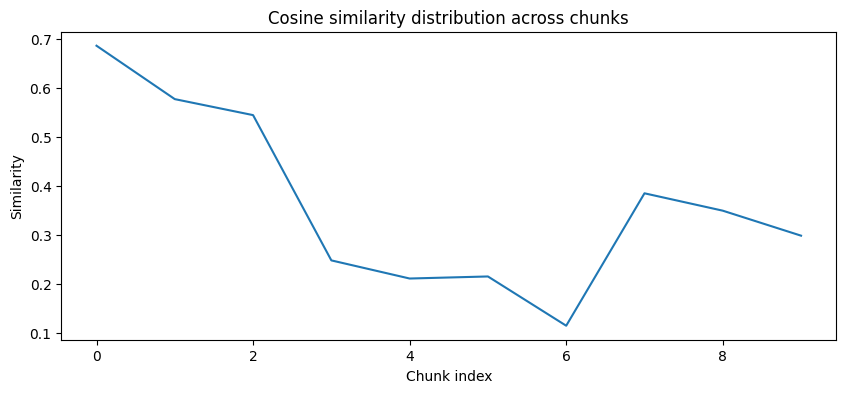

In [12]:
query = "What is NumPy used for?"
q_emb = model.encode([query], convert_to_numpy=True)
q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)

sims = (emb_norm @ q_emb.T).flatten()

plt.figure(figsize=(10,4))
plt.plot(sims)
plt.title("Cosine similarity distribution across chunks")
plt.xlabel("Chunk index")
plt.ylabel("Similarity")
plt.show()


In [14]:
print(
    "Ошибки mini‑RAG возникают, когда retrieval возвращает частично релевантные чанки "
    "или когда несколько чанков имеют близкие значения близости. "
    "Основные причины — маленькая база знаний, отсутствие reranking и короткие чанки."
)


Ошибки mini‑RAG возникают, когда retrieval возвращает частично релевантные чанки или когда несколько чанков имеют близкие значения близости. Основные причины — маленькая база знаний, отсутствие reranking и короткие чанки.
